# 1 Load the dataset1.csv and explore the data, showing size, structure and histograms of numeric data; show the histogram of the frequencies of the class labels, contained in the “y” column . . 

In [64]:
import pandas as pd

df1 = pd.read_csv('written-test-2022-02-07-exam-superv.csv')

In [65]:
print(f"The data has {df1.shape[0]} rows and {df1.shape[1]} columns")
df1.info()
print('-------------------------------------------------')
df1.describe()

The data has 1200 rows and 4 columns
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       1200 non-null   float64
 1   1       1200 non-null   float64
 2   y       1200 non-null   int64  
 3   2       1200 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 37.6 KB
-------------------------------------------------


,0,1,y,2
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.391668,1.996186,0.507500,2.494236
std,0.804770,0.507227,0.500152,0.589235
min,0.343023,0.509424,0.000000,1.500260
25%,1.806657,1.809635,0.000000,1.974389
50%,2.744439,1.983524,1.000000,2.469778
75%,3.092275,2.201484,1.000000,2.995198
max,3.529782,3.647299,1.000000,3.498523


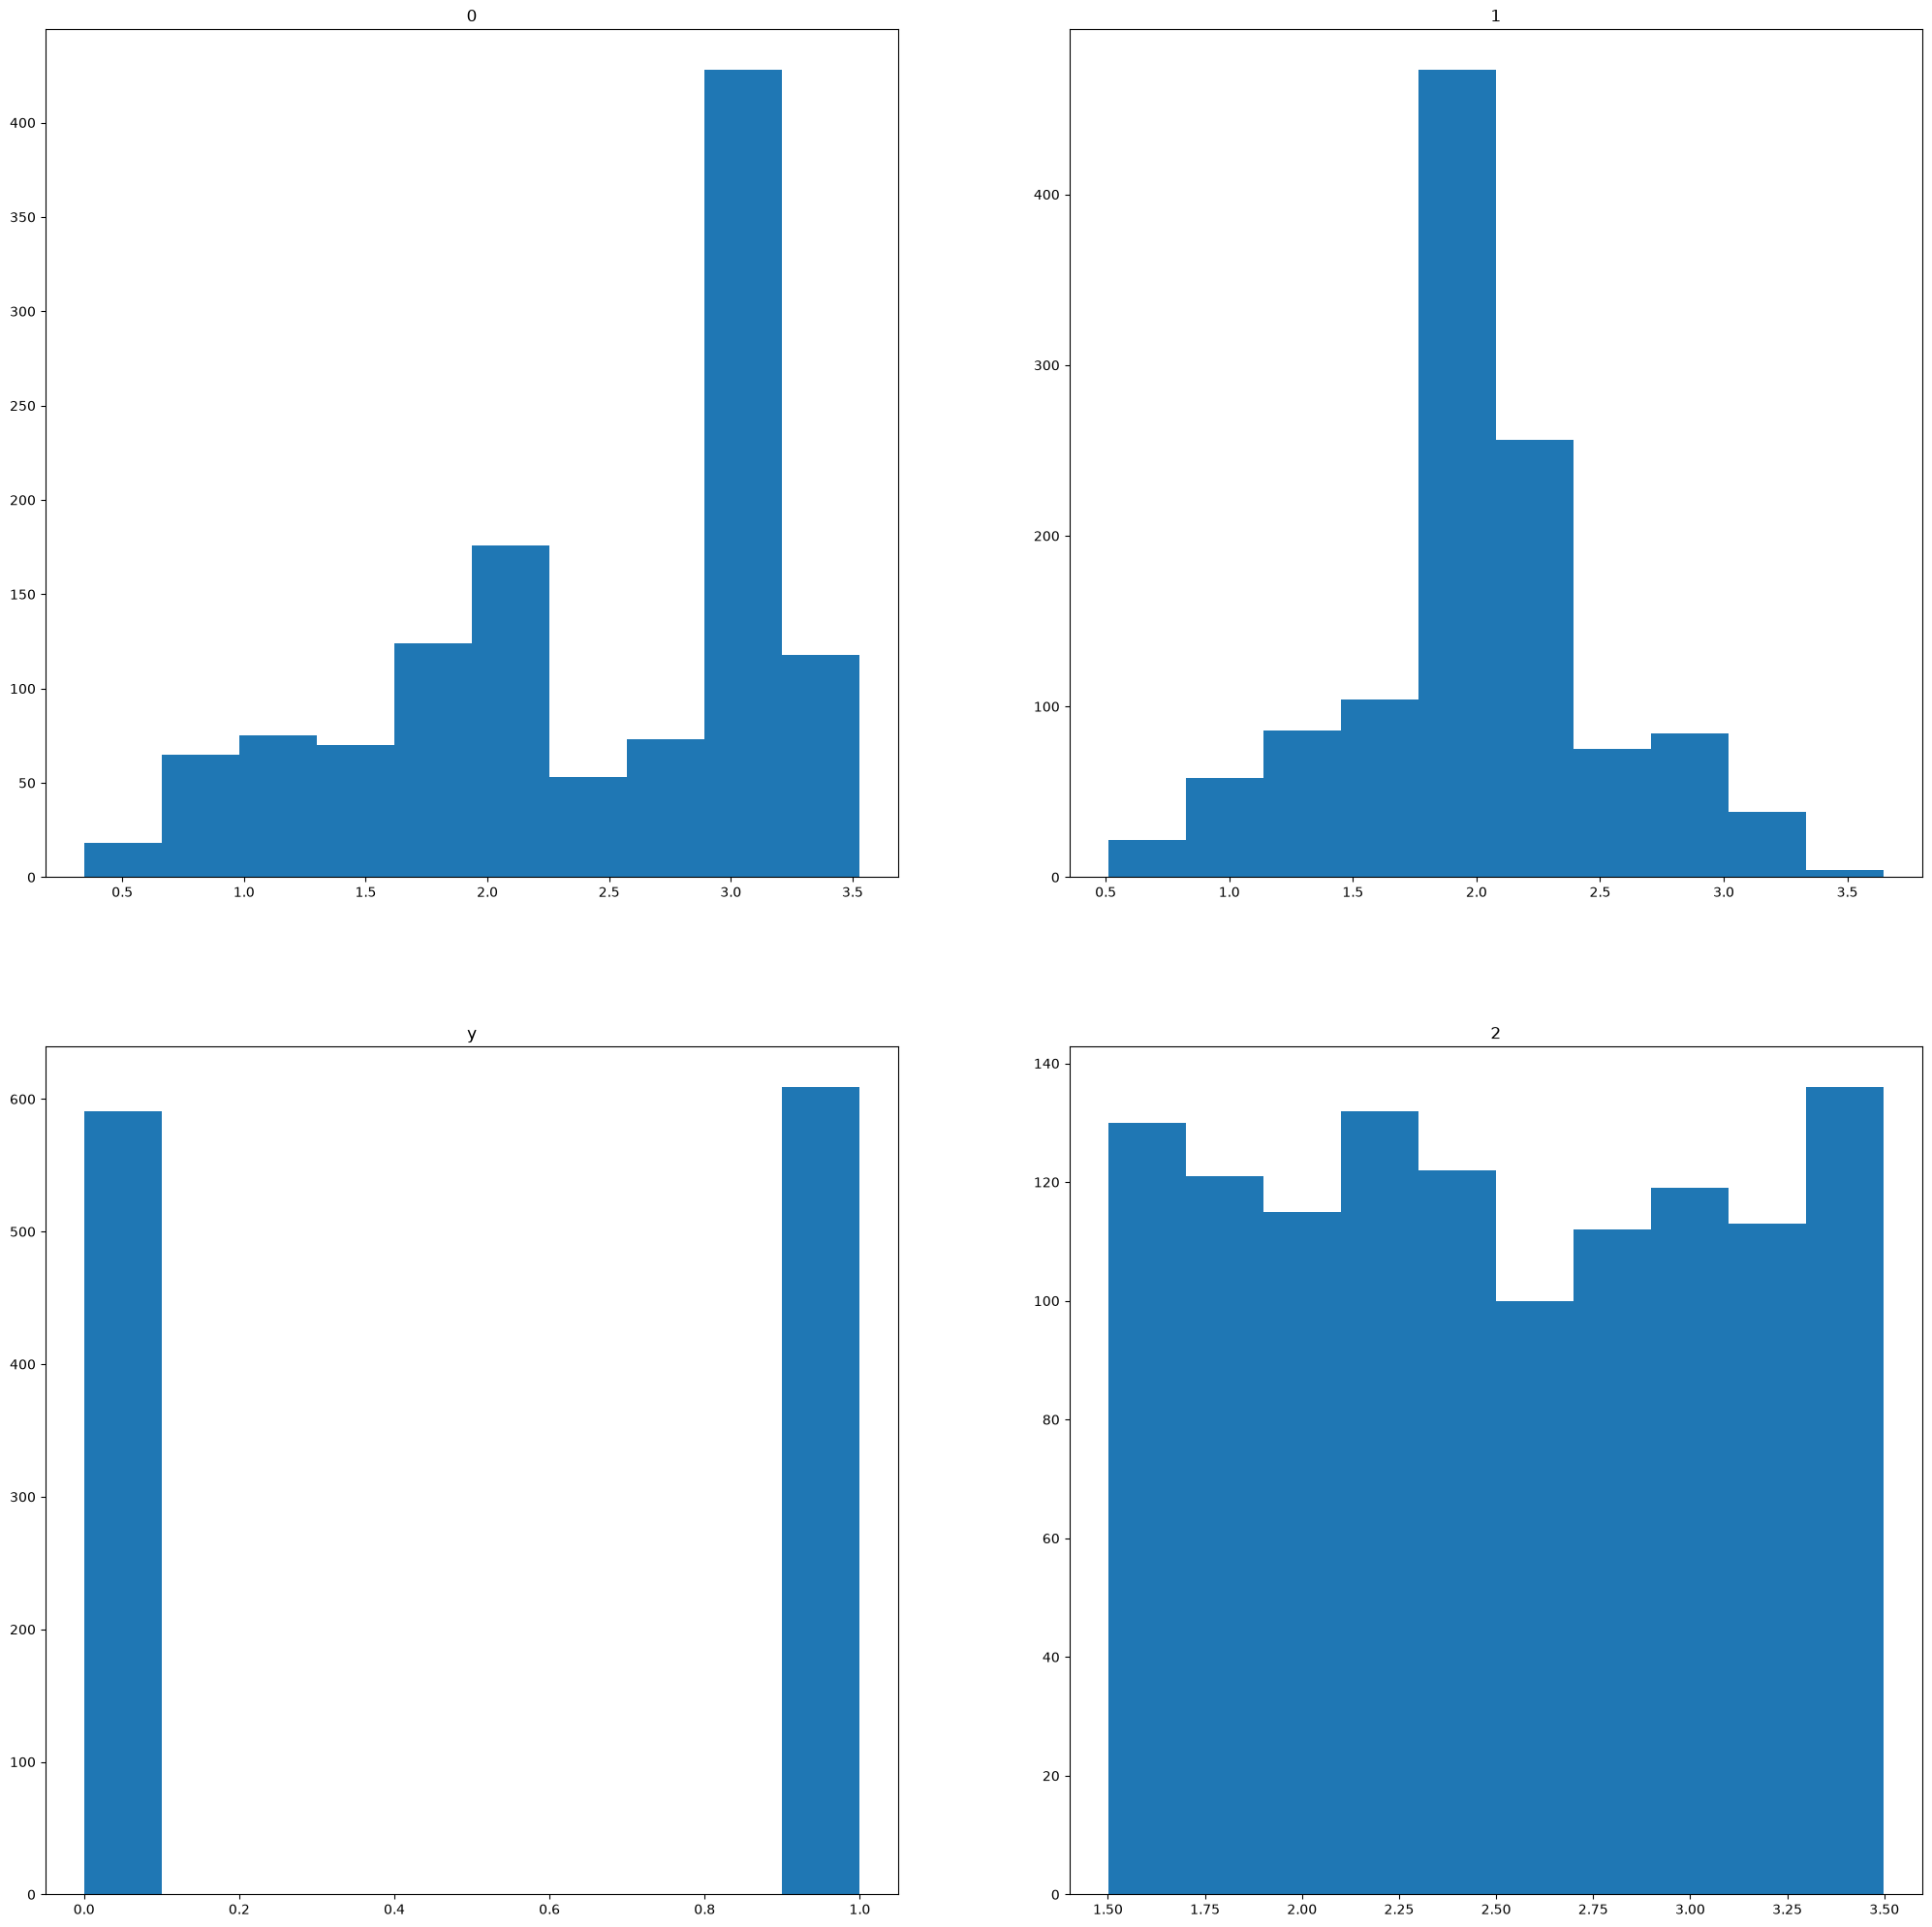

In [66]:
import matplotlib.pyplot as plt


fig = plt.figure(figsize=(25,25))
for pos, col in enumerate(df1.columns, start=1):
    plt.subplot(2,2,pos)
    plt.hist(df1[col])
    plt.title(col)
plt.show()

# 2 drop the column “y” and ﬁnd the best clustering scheme and hyper–parameters able to reproduce the y column (hint: before clustering you can consider dropping columns with little correlation to “y”; perhaps you should consider more than one estimator for clustering) 

<Axes: >

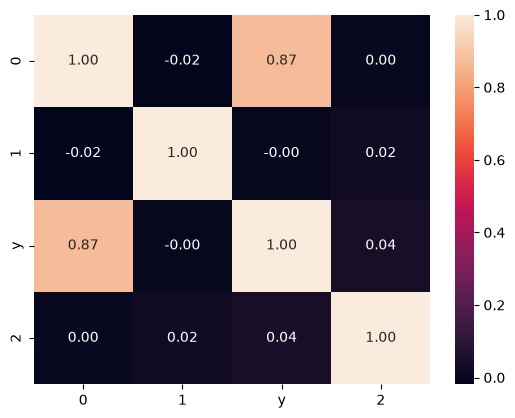

In [67]:
import seaborn as sns 

sns.heatmap(df1.corr(), annot=True, fmt='.2f')

From the plot above we see that y is mostly correlated to column 0 while columns 1 and 2 show 0 and 0.04 correlation which means no correlatation with y, so we might as well drop them

In [68]:
X = df1.drop(columns = ['1','y','2'])

In [134]:
from sklearn.cluster import KMeans
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import silhouette_score

grid_km = {'init': ['k-means++','random'],
            'n_clusters': [2],
            'n_init': [10]}

results_km=[]
for params in ParameterGrid(grid_km):
    km = KMeans(**params)
    labels_km = km.fit_predict(X)
    results_km.append({**params,
                        'silhouette score': silhouette_score(X,labels_km),
                        'inertia':km.inertia_})

resutls_km = pd.DataFrame(results_km).sort_values('silhouette score', ascending=False)
print(resutls_km)

        init  n_clusters  n_init  silhouette score     inertia
0  k-means++           2      10          0.708861  165.378337
1     random           2      10          0.708861  165.378337


In [135]:
from sklearn.cluster import AgglomerativeClustering

grid_agg = {'linkage': ['ward','complete', 'average','single'],
            'n_clusters': [2]}

results_agg=[]
for params in ParameterGrid(grid_agg):
    agg = AgglomerativeClustering(**params)
    labels_agg = agg.fit_predict(X)
    results_agg.append({**params,
                        'silhouette score': silhouette_score(X,labels_agg)})

resutls_agg = pd.DataFrame(results_agg).sort_values('silhouette score', ascending=False)
print(resutls_agg)

    linkage  n_clusters  silhouette score
2   average           2          0.710944
0      ward           2          0.708720
1  complete           2          0.589318
3    single           2          0.447268


In [136]:
from sklearn.cluster import DBSCAN

grid_dbscan = {'eps': [0.05,0.5,0.7],
                'min_samples': list(range(1,11))}

results_dbscan=[]
for params in ParameterGrid(grid_dbscan):
    dbscan = DBSCAN(**params)
    labels_dbscan = dbscan.fit_predict(X)
    n_clusters = len(set(labels_dbscan)-{-1})
    cluster_sizes= pd.Series(labels_dbscan).value_counts(normalize=True)
    largest_cluster=cluster_sizes.max()*100
    if n_clusters >=2:
        mask = labels_dbscan != -1
        results_dbscan.append({**params,
                        'n_clusters(without noise)': n_clusters,
                        'silhouette score': silhouette_score(X[mask],labels_dbscan[mask]),
                        'noise%': cluster_sizes.get(-1,0) * 100,
                        'largest_cluster':largest_cluster})

results_dbscan = pd.DataFrame(results_dbscan).sort_values(["silhouette score","noise%"], ascending=[False,True])
print(results_dbscan)


    eps  min_samples  n_clusters(without noise)  silhouette score    noise%  \
5  0.05           10                          2          0.714833  1.000000   
4  0.05            9                          2          0.714326  0.916667   
1  0.05            2                          2          0.425565  0.083333   
2  0.05            3                          2          0.425565  0.083333   
3  0.05            4                          2          0.425565  0.083333   
0  0.05            1                          3          0.424357  0.000000   

   largest_cluster  
5        51.500000  
4        51.500000  
1        99.583333  
2        99.583333  
3        99.583333  
0        99.583333  


In [137]:
from sklearn.metrics import silhouette_samples
import numpy as np
def silhouette_plot(X, label, title):
    y=0
    sil = silhouette_samples(X, label)
    print(np.unique(label))
    for c in np.unique(label):
        v = np.sort(sil[label==c]) #get the silhuette coefficients for the current cluster
        plt.barh(range(y,y+len(v)),v, height=1.0)
        y+=len(v)
        print({c: np.sum(label == c) for c in np.unique(label)})
    plt.axvline(sil.mean(),color='black',ls='--')
    plt.title(title)
    plt.show()

[0 1]
{np.int32(0): np.int64(659), np.int32(1): np.int64(541)}
{np.int32(0): np.int64(659), np.int32(1): np.int64(541)}


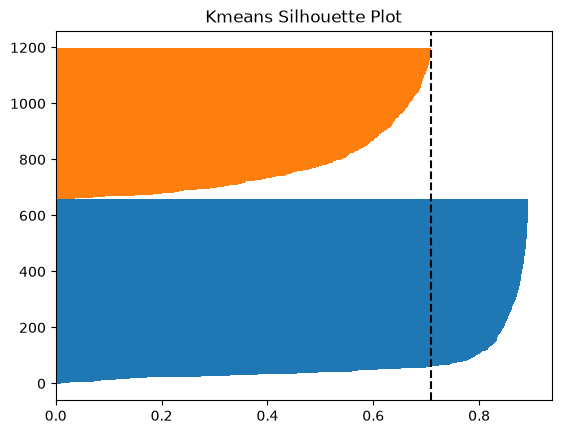

In [138]:
best_param_km = resutls_km.sort_values('silhouette score', ascending=False).iloc[0]

km_best = KMeans(init=best_param_km['init'],n_clusters=best_param_km['n_clusters'],n_init=best_param_km['n_init'])
labels_km_best = km_best.fit_predict(X)
silhouette_plot(X,labels_km_best,'Kmeans Silhouette Plot')

<Axes: >

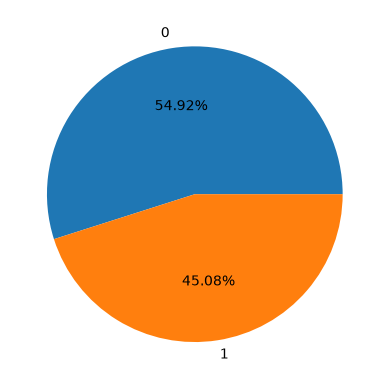

In [139]:
pd.Series(labels_km_best).sort_values().value_counts().plot(kind='pie',autopct='%.2f%%')

[0 1]
{np.int64(0): np.int64(577), np.int64(1): np.int64(623)}
{np.int64(0): np.int64(577), np.int64(1): np.int64(623)}


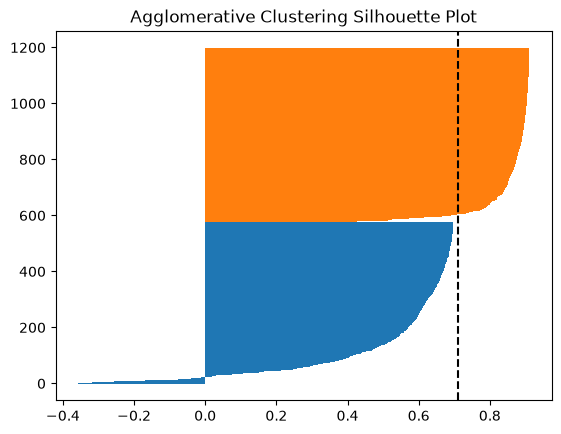

In [140]:
agg = resutls_agg.sort_values('silhouette score', ascending=False).iloc[0]

agg_best = AgglomerativeClustering(linkage=agg['linkage'],n_clusters=agg['n_clusters'])
labels_agg_best = agg_best.fit_predict(X)
silhouette_plot(X,labels_agg_best,'Agglomerative Clustering Silhouette Plot')

<Axes: >

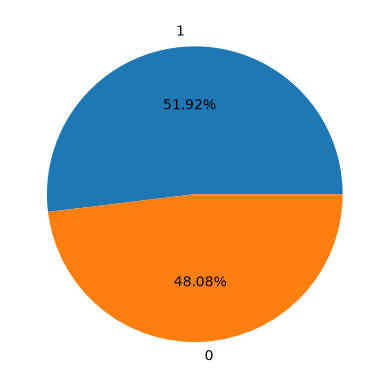

In [141]:
pd.Series(labels_agg_best).sort_values().value_counts().plot(kind='pie',autopct='%.2f%%')

[-1  0  1]
{np.int64(-1): np.int64(12), np.int64(0): np.int64(570), np.int64(1): np.int64(618)}
{np.int64(-1): np.int64(12), np.int64(0): np.int64(570), np.int64(1): np.int64(618)}
{np.int64(-1): np.int64(12), np.int64(0): np.int64(570), np.int64(1): np.int64(618)}


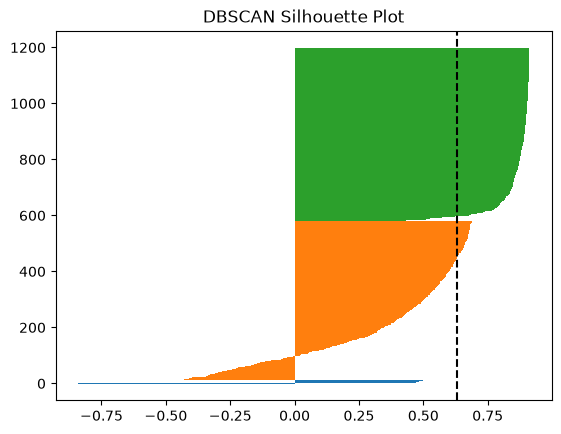

In [142]:
best_param_dbscan = resutls_dbscan.sort_values(["silhouette score","noise%"], ascending=[False,True]).iloc[0]


dbscan_best = DBSCAN(eps=best_param_dbscan['eps'],min_samples=int(best_param_dbscan['min_samples']))
labels_dbscan_best = dbscan_best.fit_predict(X)

silhouette_plot(X,labels_dbscan_best,'DBSCAN Silhouette Plot')

[-1  0  1]
True


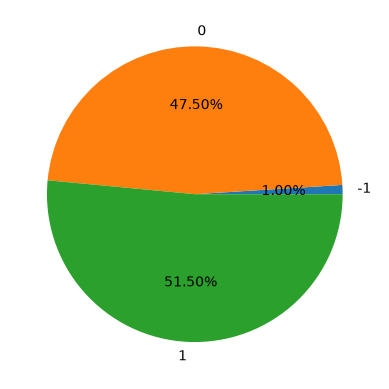

In [143]:
pd.Series(labels_dbscan_best).value_counts().sort_values().plot(kind='pie',autopct='%.2f%%')

print(np.unique(labels_dbscan_best))
print(-1 in labels_dbscan_best)

# 3 how the diﬀerence between the original “y” column and the labels generated by the clustering, it can be expressed as “accuracy”, produce also the confusion matrix . . 

K-means accuracy: 0.04


<Axes: >

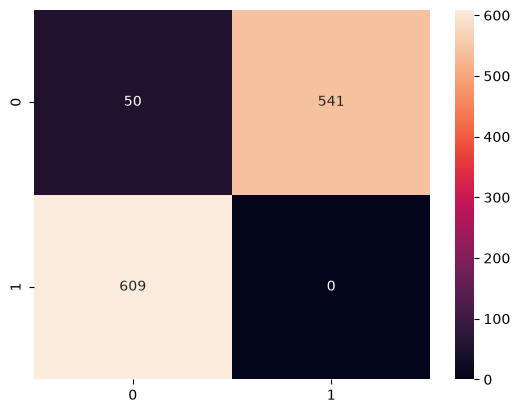

In [152]:
from sklearn.metrics import confusion_matrix, accuracy_score

acc_km = accuracy_score(df1['y'],labels_km_best)
print(f"K-means accuracy: {acc_km:.2f}")
cm_km = confusion_matrix(df1['y'],labels_km_best)

sns.heatmap(cm_km,annot=True,fmt='d')


Agglomerative accuracy: 0.99


<Axes: >

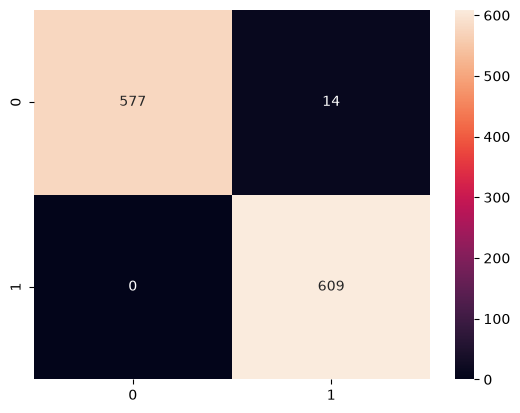

In [154]:
acc_agg = accuracy_score(df1['y'],labels_agg_best)
print(f"Agglomerative accuracy: {acc_agg:.2f}")
cm_agg = confusion_matrix(df1['y'],labels_agg_best)

sns.heatmap(cm_agg,annot=True,fmt='d')

DBSCAN accuracy: 0.98


<Axes: >

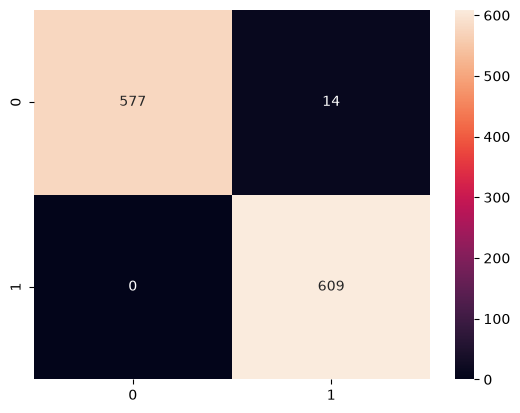

In [155]:
acc_dbscan = accuracy_score(df1['y'],labels_dbscan_best)
print(f"DBSCAN accuracy: {acc_dbscan:.2f}")
cm_dbscan = confusion_matrix(df1['y'],labels_agg_best)

sns.heatmap(cm_dbscan,annot=True,fmt='d')

# 4 apply the same transformations, to dataset2.csv, then apply the best clustering scheme and hyper parameters and plot the data with the assigned labels . 